# Unified Results -- Case Study 1 + Case Study 2 (18 experiment x variant runs)

## 1. Fetch repository

In [1]:
import urllib.request
import zipfile
import sys
from pathlib import Path

REPO_URL = "https://github.com/EnomisLP/DiverseVul--IS-Project.git"
REPO_BRANCH = "simo"

WORKSPACE_ROOT = Path.cwd()
REPO_ROOT = WORKSPACE_ROOT / "DiverseVul--IS-Project"
PROJECT_DIR = REPO_ROOT / "vuln-detection"
SRC_DIR = PROJECT_DIR / "src"

if not REPO_ROOT.exists():
    clean_url = REPO_URL.removesuffix(".git")
    zip_url = f"{clean_url}/archive/refs/heads/{REPO_BRANCH}.zip"
    zip_path = WORKSPACE_ROOT / "repo_temp.zip"

    urllib.request.urlretrieve(zip_url, zip_path)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(WORKSPACE_ROOT)

    repo_name = clean_url.split("/")[-1]
    extracted_folder = WORKSPACE_ROOT / f"{repo_name}-{REPO_BRANCH}"
    if extracted_folder.exists():
        extracted_folder.rename(REPO_ROOT)

    zip_path.unlink()

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Repository:", REPO_ROOT)
print("Source dir:", SRC_DIR)


Repository: /workspace/DiverseVul--IS-Project
Source dir: /workspace/DiverseVul--IS-Project/vuln-detection/src


In [2]:
import importlib.util
import subprocess

# Result files are saved as .parquet by the experiment notebooks; pandas
# needs pyarrow (or fastparquet) to read them, and this environment may not
# have it preinstalled -- without this, load_predictions() below fails with
# ImportError instead of the intended "directory not found" / graceful skip.
if importlib.util.find_spec("pyarrow") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyarrow"], check=True)
    print("Installed pyarrow.")
else:
    print("pyarrow already available.")


pyarrow already available.


## 2. Output roots

In [3]:
DATA_ROOT = WORKSPACE_ROOT / "IntelligentSystemProject" / "VulnerabilityDetectionData"
OUTPUT_ROOT = DATA_ROOT / "outputs"

EXPERIMENT_ID = "cs1_project_holdout20_innercv_v1"
CS1_EXPERIMENT_OUTPUT_DIR = OUTPUT_ROOT / EXPERIMENT_ID
CS2_OUTPUT_ROOT = OUTPUT_ROOT / "case_study_2"

RESULTS_OUTPUT_DIR = OUTPUT_ROOT / "unified_results_summary"
RESULTS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# New: a dedicated folder for all figures (PNG + PDF), separate from the CSV
# / manifest outputs above. Cross-experiment "unified" plots live directly in
# this folder; each experiment additionally gets its own subfolder with its
# own PR curve and confusion matrix (see the "Per-experiment figures" cell).
FIGURES_DIR = OUTPUT_ROOT / "unified_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("CS1_EXPERIMENT_OUTPUT_DIR:", CS1_EXPERIMENT_OUTPUT_DIR)
print("CS2_OUTPUT_ROOT:", CS2_OUTPUT_ROOT)
print("RESULTS_OUTPUT_DIR:", RESULTS_OUTPUT_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

OUTPUT_ROOT: /workspace/IntelligentSystemProject/VulnerabilityDetectionData/outputs
CS1_EXPERIMENT_OUTPUT_DIR: /workspace/IntelligentSystemProject/VulnerabilityDetectionData/outputs/cs1_project_holdout20_innercv_v1
CS2_OUTPUT_ROOT: /workspace/IntelligentSystemProject/VulnerabilityDetectionData/outputs/case_study_2
RESULTS_OUTPUT_DIR: /workspace/IntelligentSystemProject/VulnerabilityDetectionData/outputs/unified_results_summary
FIGURES_DIR: /workspace/IntelligentSystemProject/VulnerabilityDetectionData/outputs/unified_figures


## 3. Experiment matrix definition

In [4]:
VARIANTS = ["normalized", "abstracted"]

EXPERIMENT_SPECS = [
    {
        "id": "EXP-0",
        "case_study": 1,
        "pipeline": "Logistic Regression",
        "backbone": None,
        "dirs": lambda tag: {
            "dev": OUTPUT_ROOT / f"exp0_idabs_nested_alpha_development_only_v2_reproduction_{tag}",
            "holdout": OUTPUT_ROOT / f"exp0_idabs_nested_alpha_development_only_v2_reproduction_{tag}",
        },
    },
    {
        "id": "EXP-1",
        "case_study": 1,
        "pipeline": "Random Forest",
        "backbone": None,
        "dirs": lambda tag: {
            "dev": CS1_EXPERIMENT_OUTPUT_DIR / f"exp1_rf_idabs_dev_cv_v1_{tag}",
            "holdout": CS1_EXPERIMENT_OUTPUT_DIR / f"exp1_rf_idabs_final_holdout_v1_{tag}",
        },
    },
    {
        "id": "EXP-2",
        "case_study": 1,
        "pipeline": "MLP",
        "backbone": None,
        "dirs": lambda tag: {
            "dev": CS1_EXPERIMENT_OUTPUT_DIR / f"exp2_mlp_idabs_dev_cv_v2_{tag}",
            "holdout": CS1_EXPERIMENT_OUTPUT_DIR / f"exp2_mlp_idabs_final_holdout_v2_{tag}",
        },
    },
    {
        "id": "EXP-3",
        "case_study": 2,
        "pipeline": "Linear Probe",
        "backbone": "CodeBERTa",
        "dirs": lambda tag: {
            "dev": CS2_OUTPUT_ROOT / f"exp3_codeberta_linear_probe_v1_{tag}",
            "holdout": CS2_OUTPUT_ROOT / f"exp3_codeberta_linear_probe_v1_{tag}",
        },
    },
    {
        "id": "EXP-4",
        "case_study": 2,
        "pipeline": "LoRA",
        "backbone": "CodeBERTa",
        "dirs": lambda tag: {
            "dev": CS2_OUTPUT_ROOT / f"exp4_codeberta_lora_v1_{tag}",
            "holdout": CS2_OUTPUT_ROOT / f"exp4_codeberta_lora_v1_{tag}",
        },
    },
    {
        "id": "EXP-5",
        "case_study": 2,
        "pipeline": "HEFT",
        "backbone": "CodeBERTa",
        "dirs": lambda tag: {
            "dev": CS2_OUTPUT_ROOT / f"exp5_codeberta_heft_v1_{tag}",
            "holdout": CS2_OUTPUT_ROOT / f"exp5_codeberta_heft_v1_{tag}",
        },
    },
    {
        "id": "EXP-6",
        "case_study": 2,
        "pipeline": "Linear Probe",
        "backbone": "NeoBERT",
        "dirs": lambda tag: {
            "dev": CS2_OUTPUT_ROOT / f"exp6_neobert_linear_probe_v1_{tag}",
            "holdout": CS2_OUTPUT_ROOT / f"exp6_neobert_linear_probe_v1_{tag}",
        },
    },
    {
        "id": "EXP-7",
        "case_study": 2,
        "pipeline": "LoRA",
        "backbone": "NeoBERT",
        "dirs": lambda tag: {
            "dev": CS2_OUTPUT_ROOT / f"exp7_neobert_lora_v1_{tag}",
            "holdout": CS2_OUTPUT_ROOT / f"exp7_neobert_lora_v1_{tag}",
        },
    },
    {
        "id": "EXP-8",
        "case_study": 2,
        "pipeline": "HEFT",
        "backbone": "NeoBERT",
        "dirs": lambda tag: {
            "dev": CS2_OUTPUT_ROOT / f"exp8_neobert_heft_v1_{tag}",
            "holdout": CS2_OUTPUT_ROOT / f"exp8_neobert_heft_v1_{tag}",
        },
    },
]

print(f"{len(EXPERIMENT_SPECS)} experiments x {len(VARIANTS)} variants = {len(EXPERIMENT_SPECS) * len(VARIANTS)} possible runs.")


9 experiments x 2 variants = 18 possible runs.


## 4. Predictions loader

In [5]:
import pandas as pd


def load_predictions(directory, pattern):
    matches = sorted(directory.glob(pattern))
    if not matches:
        matches = sorted(directory.glob(pattern.replace(".parquet", ".csv")))
    if not matches:
        raise FileNotFoundError(f"No file matching '{pattern}' found in {directory}")
    if len(matches) > 1:
        raise RuntimeError(f"Multiple files matching '{pattern}' found in {directory}: {matches}")
    path = matches[0]
    if path.suffix == ".parquet":
        return pd.read_parquet(path)
    return pd.read_csv(path)


## 5. Discover and load available runs

In [6]:
records = []
missing = []

for spec in EXPERIMENT_SPECS:
    for tag in VARIANTS:
        dirs = spec["dirs"](tag)
        dev_dir, holdout_dir = dirs["dev"], dirs["holdout"]

        if not dev_dir.exists() or not holdout_dir.exists():
            missing.append((spec["id"], tag, "directory not found"))
            continue

        try:
            dev_predictions = load_predictions(dev_dir, "*oof_predictions*.parquet")
            holdout_predictions = load_predictions(holdout_dir, "*holdout_predictions*.parquet")
        except (FileNotFoundError, RuntimeError) as exc:
            missing.append((spec["id"], tag, str(exc)))
            continue

        records.append({
            "spec": spec,
            "tag": tag,
            "dev_predictions": dev_predictions,
            "holdout_predictions": holdout_predictions,
        })

print(f"Loaded {len(records)} / {len(EXPERIMENT_SPECS) * len(VARIANTS)} experiment x variant combinations.")
print()
print("Loaded:")
for r in records:
    print(f"  - {r['spec']['id']} [{r['tag']}]: dev={len(r['dev_predictions'])} rows, holdout={len(r['holdout_predictions'])} rows")
print()
print("Not yet available:")
for exp_id, tag, reason in missing:
    print(f"  - {exp_id} [{tag}]: {reason}")
print()
if records:
    print(f"Proceeding with the {len(records)} available run(s) only; all outputs below reflect this run's partial results and overwrite any previous unified_results_summary output.")
else:
    print("No experiment outputs are available yet; downstream cells will still run and produce empty (but valid) summary files.")


Loaded 10 / 18 experiment x variant combinations.

Loaded:
  - EXP-0 [normalized]: dev=203958 rows, holdout=57709 rows
  - EXP-0 [abstracted]: dev=203958 rows, holdout=57709 rows
  - EXP-1 [normalized]: dev=203958 rows, holdout=57709 rows
  - EXP-1 [abstracted]: dev=203958 rows, holdout=57709 rows
  - EXP-2 [normalized]: dev=203958 rows, holdout=57709 rows
  - EXP-2 [abstracted]: dev=203958 rows, holdout=57709 rows
  - EXP-6 [normalized]: dev=203958 rows, holdout=57709 rows
  - EXP-6 [abstracted]: dev=203958 rows, holdout=57709 rows
  - EXP-7 [normalized]: dev=203958 rows, holdout=57709 rows
  - EXP-7 [abstracted]: dev=203958 rows, holdout=57709 rows

Not yet available:
  - EXP-3 [normalized]: directory not found
  - EXP-3 [abstracted]: directory not found
  - EXP-4 [normalized]: directory not found
  - EXP-4 [abstracted]: directory not found
  - EXP-5 [normalized]: directory not found
  - EXP-5 [abstracted]: directory not found
  - EXP-8 [normalized]: directory not found
  - EXP-8 [ab

## 6. Holdout partition consistency check

In [7]:
if records:
    reference = records[0]
    reference_projects = set(reference["holdout_predictions"]["project"].unique())
    inconsistent = []
    for r in records[1:]:
        projects = set(r["holdout_predictions"]["project"].unique())
        if projects != reference_projects:
            inconsistent.append(f"{r['spec']['id']} [{r['tag']}]")

    if inconsistent:
        print("WARNING: holdout partition differs from the reference run for:", inconsistent)
        print("Reference:", f"{reference['spec']['id']} [{reference['tag']}]", "with", len(reference_projects), "projects")
    else:
        print(f"All {len(records)} loaded runs share the identical {len(reference_projects)}-project outer holdout.")
else:
    print("No runs loaded yet; nothing to validate.")


All 10 loaded runs share the identical 203-project outer holdout.


## 7. Bootstrap confidence intervals (PR-AUC, precision, recall, F1)

In [8]:
import case_study_1.confidence_intervals as confidence_intervals

# Every metric reported downstream needs a CI, not just PR-AUC: precision/
# recall/F1 are threshold-dependent (fixed at 0.5, matching this project's
# existing decision-threshold convention -- see PDD Section 7.5), so their
# bootstrap CI also reflects that fixed threshold choice, not sampling
# variance alone (see confidence_intervals.py's module docstring).
CI_METRICS = ["average_precision_pr_auc", "precision", "recall", "f1"]

for r in records:
    r["ci"] = {
        split: {
            metric: confidence_intervals.bootstrap_metric_ci(
                r[f"{split}_predictions"],
                metric=metric,
                n_bootstrap=1000,
                random_state=42,
            )
            for metric in CI_METRICS
        }
        for split in ("dev", "holdout")
    }
    dev_pr_auc = r["ci"]["dev"]["average_precision_pr_auc"].point_estimate
    holdout_pr_auc = r["ci"]["holdout"]["average_precision_pr_auc"].point_estimate
    holdout_f1 = r["ci"]["holdout"]["f1"].point_estimate
    print(
        f"{r['spec']['id']} [{r['tag']}]: dev PR-AUC={dev_pr_auc:.4f}, "
        f"holdout PR-AUC={holdout_pr_auc:.4f}, holdout F1={holdout_f1:.4f}"
    )

EXP-0 [normalized]: dev PR-AUC=0.1420, holdout PR-AUC=0.1524, holdout F1=0.2032
EXP-0 [abstracted]: dev PR-AUC=0.1435, holdout PR-AUC=0.1500, holdout F1=0.1983
EXP-1 [normalized]: dev PR-AUC=0.1240, holdout PR-AUC=0.1473, holdout F1=0.0388
EXP-1 [abstracted]: dev PR-AUC=0.1303, holdout PR-AUC=0.1477, holdout F1=0.0291
EXP-2 [normalized]: dev PR-AUC=0.1342, holdout PR-AUC=0.1492, holdout F1=0.1850
EXP-2 [abstracted]: dev PR-AUC=0.1377, holdout PR-AUC=0.1391, holdout F1=0.1775
EXP-6 [normalized]: dev PR-AUC=0.1113, holdout PR-AUC=0.1204, holdout F1=0.1693
EXP-6 [abstracted]: dev PR-AUC=0.1113, holdout PR-AUC=0.1204, holdout F1=0.1693
EXP-7 [normalized]: dev PR-AUC=0.1116, holdout PR-AUC=0.1210, holdout F1=0.1714
EXP-7 [abstracted]: dev PR-AUC=0.1234, holdout PR-AUC=0.1321, holdout F1=0.1517


## 8. Master results table

In [9]:
CI_METRICS = ["average_precision_pr_auc", "precision", "recall", "f1"]
METRIC_COLUMN_NAMES = {
    "average_precision_pr_auc": "pr_auc",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

RESULTS_COLUMNS = ["experiment", "case_study", "pipeline", "backbone", "variant"]
for split in ("dev", "holdout"):
    for metric in CI_METRICS:
        col = METRIC_COLUMN_NAMES[metric]
        RESULTS_COLUMNS += [f"{split}_{col}", f"{split}_{col}_ci_low", f"{split}_{col}_ci_high"]

rows = []
for r in records:
    spec = r["spec"]
    row = {
        "experiment": spec["id"],
        "case_study": spec["case_study"],
        "pipeline": spec["pipeline"],
        "backbone": spec["backbone"] or "-",
        "variant": r["tag"],
    }
    for split in ("dev", "holdout"):
        for metric in CI_METRICS:
            col = METRIC_COLUMN_NAMES[metric]
            ci = r["ci"][split][metric]
            row[f"{split}_{col}"] = ci.point_estimate
            row[f"{split}_{col}_ci_low"] = ci.ci_low
            row[f"{split}_{col}_ci_high"] = ci.ci_high
    rows.append(row)

# Build with an explicit column schema (not just pd.DataFrame(rows)) so this
# still produces a well-formed table -- with the right columns, just zero
# rows -- when `rows` is empty (e.g. no experiment outputs are available
# yet). Without this, pd.DataFrame([]) has no columns at all and the
# .sort_values(["case_study", ...]) call below would raise a KeyError.
if rows:
    results_table = (
        pd.DataFrame(rows, columns=RESULTS_COLUMNS)
        .sort_values(["case_study", "experiment", "variant"])
        .reset_index(drop=True)
    )
else:
    results_table = pd.DataFrame(columns=RESULTS_COLUMNS)
    print("No experiment results available yet -- writing an empty summary table.")

# Fixed filename: each run overwrites the previous unified_results_summary.csv
# with whatever is currently available, rather than accumulating history.
results_table.to_csv(RESULTS_OUTPUT_DIR / "unified_results_summary.csv", index=False)
results_table

,experiment,case_study,pipeline,backbone,variant,dev_pr_auc,dev_pr_auc_ci_low,dev_pr_auc_ci_high,dev_precision,dev_precision_ci_low,...,holdout_pr_auc_ci_high,holdout_precision,holdout_precision_ci_low,holdout_precision_ci_high,holdout_recall,holdout_recall_ci_low,holdout_recall_ci_high,holdout_f1,holdout_f1_ci_low,holdout_f1_ci_high
0,EXP-0,1,Logistic Regression,-,abstracted,0.143464,0.122964,0.170067,0.121673,0.107996,...,0.182995,0.121035,0.106273,0.139649,0.547804,0.468266,0.634540,0.198264,0.178088,0.222904
1,EXP-0,1,Logistic Regression,-,normalized,0.141977,0.121234,0.168309,0.123840,0.109928,...,0.183016,0.125364,0.110259,0.145490,0.536282,0.464722,0.621982,0.203222,0.182316,0.228706
2,EXP-1,1,Random Forest,-,abstracted,0.130284,0.109015,0.157651,0.255814,0.136830,...,0.190649,0.533333,0.266579,0.604956,0.014949,0.001546,0.043856,0.029082,0.003076,0.081608
3,EXP-1,1,Random Forest,-,normalized,0.124031,0.105837,0.150039,0.206897,0.088605,...,0.189202,0.474453,0.268276,0.529854,0.020243,0.003318,0.054682,0.038829,0.006554,0.098985
4,EXP-2,1,MLP,-,abstracted,0.137688,0.115161,0.164340,0.101507,0.089535,...,0.168702,0.103385,0.087903,0.121962,0.626908,0.563796,0.696916,0.177498,0.153503,0.205154
5,EXP-2,1,MLP,-,normalized,0.134239,0.111452,0.163340,0.102747,0.090048,...,0.176149,0.108421,0.095295,0.124324,0.630333,0.554968,0.718128,0.185018,0.164278,0.209212
6,EXP-6,2,Linear Probe,NeoBERT,abstracted,0.111347,0.094756,0.132623,0.095438,0.083027,...,0.141301,0.096912,0.083872,0.113945,0.669573,0.611833,0.737745,0.169318,0.149122,0.195819
7,EXP-6,2,Linear Probe,NeoBERT,normalized,0.111347,0.094756,0.132623,0.095438,0.083027,...,0.141301,0.096912,0.083872,0.113945,0.669573,0.611833,0.737745,0.169318,0.149122,0.195819
8,EXP-7,2,LoRA,NeoBERT,abstracted,0.123423,0.100952,0.151923,0.101306,0.087672,...,0.161690,0.083796,0.072777,0.099828,0.798505,0.751502,0.844347,0.151676,0.133273,0.178275
9,EXP-7,2,LoRA,NeoBERT,normalized,0.111600,0.096161,0.137347,0.098173,0.083899,...,0.147858,0.099636,0.086787,0.118114,0.613516,0.558801,0.674333,0.171431,0.151377,0.198563


## 9. Holdout PR-AUC by experiment and variant

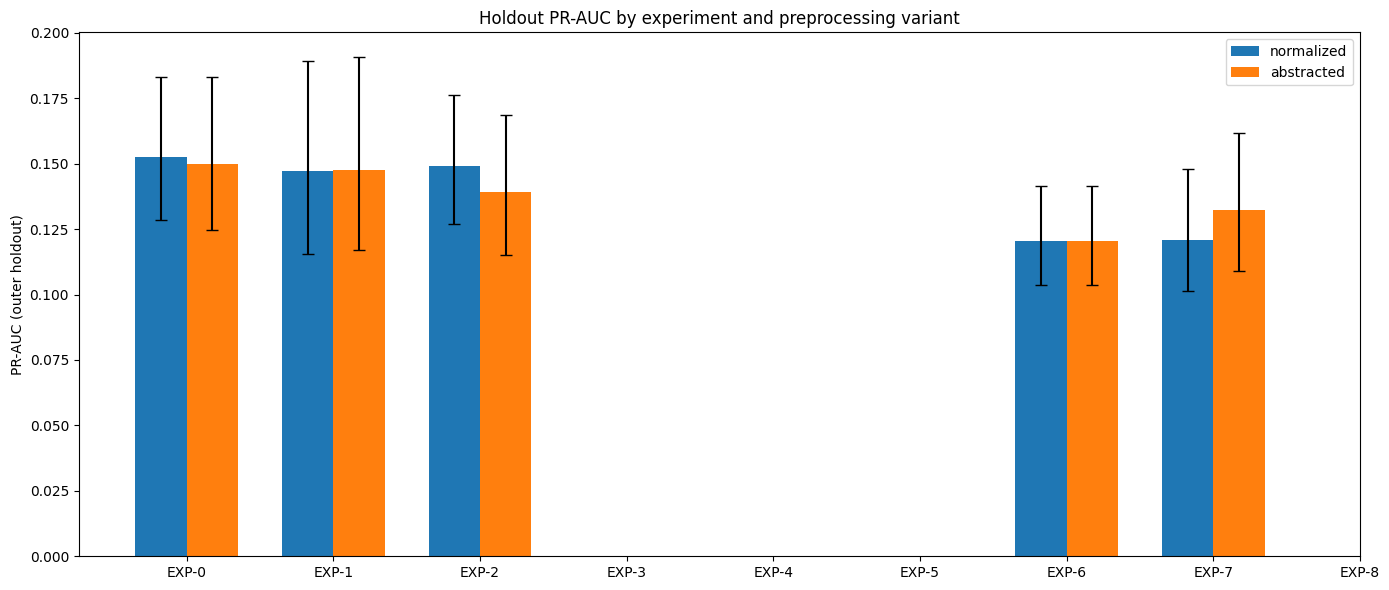

In [10]:
import matplotlib.pyplot as plt
import numpy as np

exp_ids = [s["id"] for s in EXPERIMENT_SPECS]
x = np.arange(len(exp_ids))
width = 0.35
offsets = {"normalized": -width / 2, "abstracted": width / 2}
colors = {"normalized": "tab:blue", "abstracted": "tab:orange"}

fig, ax = plt.subplots(figsize=(14, 6))
for tag in VARIANTS:
    positions = []
    points = []
    err_low = []
    err_high = []
    for i, exp_id in enumerate(exp_ids):
        match = results_table[(results_table["experiment"] == exp_id) & (results_table["variant"] == tag)]
        if match.empty:
            continue
        row = match.iloc[0]
        positions.append(x[i] + offsets[tag])
        points.append(row["holdout_pr_auc"])
        err_low.append(row["holdout_pr_auc"] - row["holdout_pr_auc_ci_low"])
        err_high.append(row["holdout_pr_auc_ci_high"] - row["holdout_pr_auc"])
    ax.bar(positions, points, width, yerr=[err_low, err_high], capsize=4, label=tag, color=colors[tag])

ax.set_xticks(x)
ax.set_xticklabels(exp_ids)
ax.set_ylabel("PR-AUC (outer holdout)")
ax.set_title("Holdout PR-AUC by experiment and preprocessing variant")
ax.legend()
plt.tight_layout()
for ext in ("png", "pdf"):
    plt.savefig(FIGURES_DIR / f"unified_holdout_pr_auc_by_variant.{ext}")
plt.show()

## 10. Precision-recall curves -- Case Study 1

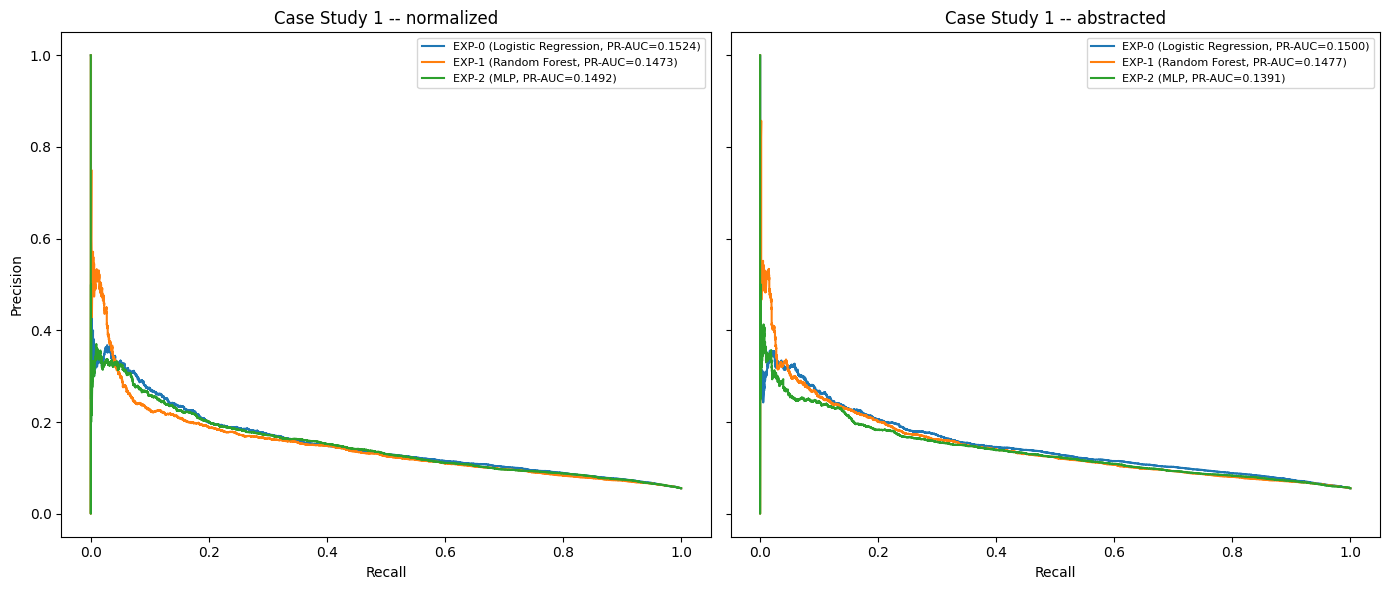

In [11]:
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, tag in zip(axes, VARIANTS):
    for r in records:
        if r["spec"]["case_study"] != 1 or r["tag"] != tag:
            continue
        frame = r["holdout_predictions"]
        precision, recall, _ = precision_recall_curve(frame["label"], frame["y_score"])
        pr_auc = r["ci"]["holdout"]["average_precision_pr_auc"].point_estimate
        ax.plot(recall, precision, label=f"{r['spec']['id']} ({r['spec']['pipeline']}, PR-AUC={pr_auc:.4f})")
    ax.set_xlabel("Recall")
    ax.set_title(f"Case Study 1 -- {tag}")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Precision")
plt.tight_layout()
for ext in ("png", "pdf"):
    plt.savefig(FIGURES_DIR / f"unified_cs1_pr_curves_holdout.{ext}")
plt.show()

## 11. Precision-recall curves -- Case Study 2

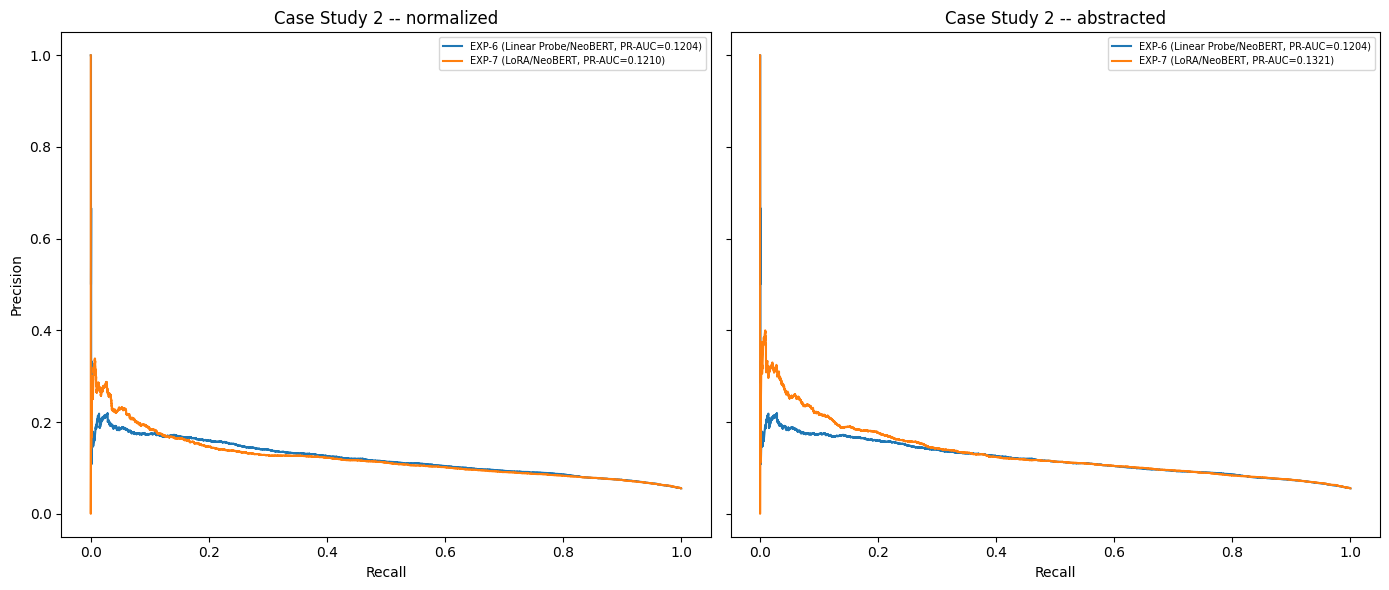

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, tag in zip(axes, VARIANTS):
    for r in records:
        if r["spec"]["case_study"] != 2 or r["tag"] != tag:
            continue
        frame = r["holdout_predictions"]
        precision, recall, _ = precision_recall_curve(frame["label"], frame["y_score"])
        pr_auc = r["ci"]["holdout"]["average_precision_pr_auc"].point_estimate
        label = f"{r['spec']['id']} ({r['spec']['pipeline']}/{r['spec']['backbone']}, PR-AUC={pr_auc:.4f})"
        ax.plot(recall, precision, label=label)
    ax.set_xlabel("Recall")
    ax.set_title(f"Case Study 2 -- {tag}")
    ax.legend(fontsize=7)
axes[0].set_ylabel("Precision")
plt.tight_layout()
for ext in ("png", "pdf"):
    plt.savefig(FIGURES_DIR / f"unified_cs2_pr_curves_holdout.{ext}")
plt.show()

## 12. Paired bootstrap comparisons

In [13]:
import itertools


def find_record(exp_id, tag):
    for r in records:
        if r["spec"]["id"] == exp_id and r["tag"] == tag:
            return r
    return None


def within_group_pairs(exp_ids):
    return [(a, tag, b, tag) for tag in VARIANTS for a, b in itertools.combinations(exp_ids, 2)]


def across_backbone_pairs(method_pairs):
    return [(a, tag, b, tag) for tag in VARIANTS for a, b in method_pairs]


def across_variant_pairs(exp_ids):
    return [(e, "normalized", e, "abstracted") for e in exp_ids]


ALL_PAIRS = (
    within_group_pairs(["EXP-0", "EXP-1", "EXP-2"])
    + within_group_pairs(["EXP-3", "EXP-4", "EXP-5"])
    + within_group_pairs(["EXP-6", "EXP-7", "EXP-8"])
    + across_backbone_pairs([("EXP-3", "EXP-6"), ("EXP-4", "EXP-7"), ("EXP-5", "EXP-8")])
    + across_variant_pairs([s["id"] for s in EXPERIMENT_SPECS])
)

paired_results = []
skipped_pairs = []
for exp_a, tag_a, exp_b, tag_b in ALL_PAIRS:
    record_a = find_record(exp_a, tag_a)
    record_b = find_record(exp_b, tag_b)
    if record_a is None or record_b is None:
        skipped_pairs.append((exp_a, tag_a, exp_b, tag_b))
        continue

    label_a = f"{exp_a} [{tag_a}]"
    label_b = f"{exp_b} [{tag_b}]"
    result = confidence_intervals.paired_bootstrap_metric_ci(
        record_a["holdout_predictions"],
        record_b["holdout_predictions"],
        label_a,
        label_b,
        n_bootstrap=1000,
        random_state=42,
    )
    paired_results.append(result)

print(f"Computed {len(paired_results)} paired comparisons; skipped {len(skipped_pairs)} (missing run on at least one side).")


Computed 13 paired comparisons; skipped 20 (missing run on at least one side).


## 13. Save paired comparison table

In [14]:
PAIRED_COLUMNS = [
    "comparison_a", "comparison_b", "pr_auc_a", "pr_auc_b",
    "difference", "ci_low", "ci_high", "significant",
]

paired_rows = [
    {
        "comparison_a": result.experiment_a,
        "comparison_b": result.experiment_b,
        "pr_auc_a": result.point_estimate_a,
        "pr_auc_b": result.point_estimate_b,
        "difference": result.point_estimate_diff,
        "ci_low": result.ci_low_diff,
        "ci_high": result.ci_high_diff,
        "significant": (result.ci_low_diff > 0) or (result.ci_high_diff < 0),
    }
    for result in paired_results
]

# Explicit column schema (not just pd.DataFrame(paired_rows)) so this is
# still well-formed -- right columns, zero rows -- when no pair could be
# computed yet (e.g. too few experiments loaded to match any of ALL_PAIRS).
# Downstream (cell 14) filters on paired_table["comparison_a"], which would
# raise a KeyError on a columnless empty DataFrame otherwise.
paired_table = pd.DataFrame(paired_rows, columns=PAIRED_COLUMNS)
if not paired_rows:
    print("No paired comparisons available yet -- writing an empty comparison table.")

# Fixed filename: each run overwrites the previous comparison table with
# whatever pairs are currently computable, rather than accumulating history.
paired_table.to_csv(RESULTS_OUTPUT_DIR / "unified_paired_holdout_comparisons.csv", index=False)
paired_table


,comparison_a,comparison_b,pr_auc_a,pr_auc_b,difference,ci_low,ci_high,significant
0,EXP-0 [normalized],EXP-1 [normalized],0.152404,0.147319,0.005085,-0.011144,0.020577,False
1,EXP-0 [normalized],EXP-2 [normalized],0.152404,0.149193,0.003211,-0.003648,0.010691,False
2,EXP-1 [normalized],EXP-2 [normalized],0.147319,0.149193,-0.001874,-0.018777,0.017534,False
3,EXP-0 [abstracted],EXP-1 [abstracted],0.149973,0.147739,0.002234,-0.016158,0.020397,False
4,EXP-0 [abstracted],EXP-2 [abstracted],0.149973,0.139073,0.010901,0.001128,0.020247,True
5,EXP-1 [abstracted],EXP-2 [abstracted],0.147739,0.139073,0.008666,-0.008521,0.029409,False
6,EXP-6 [normalized],EXP-7 [normalized],0.120369,0.120963,-0.000594,-0.010997,0.008315,False
7,EXP-6 [abstracted],EXP-7 [abstracted],0.120369,0.132121,-0.011752,-0.025750,0.000284,False
8,EXP-0 [normalized],EXP-0 [abstracted],0.152404,0.149973,0.002430,-0.002688,0.007220,False
9,EXP-1 [normalized],EXP-1 [abstracted],0.147319,0.147739,-0.000420,-0.008324,0.008896,False


## 14. Does abstraction help? Summary view

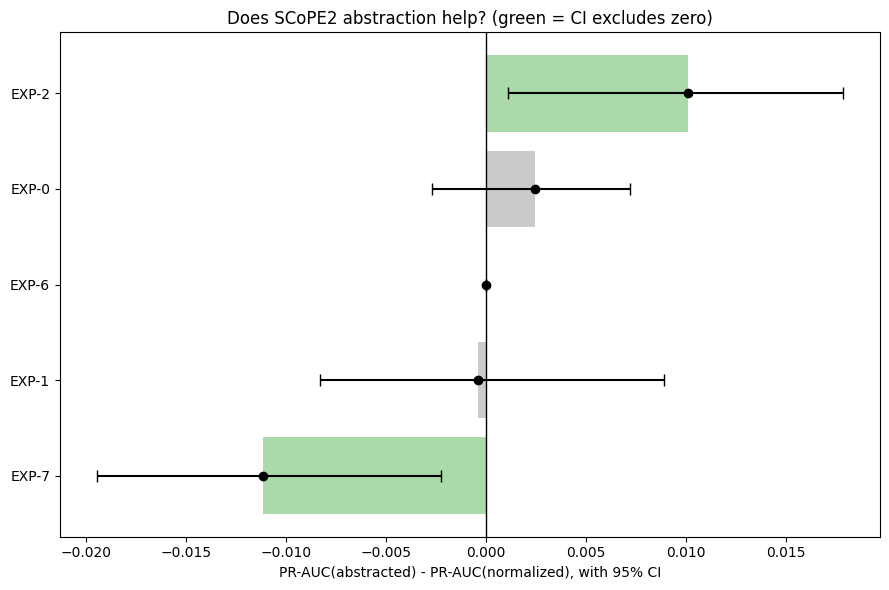

,comparison_a,comparison_b,pr_auc_a,pr_auc_b,difference,ci_low,ci_high,significant,experiment
12,EXP-7 [normalized],EXP-7 [abstracted],0.120963,0.132121,-0.011158,-0.019462,-0.002237,True,EXP-7
9,EXP-1 [normalized],EXP-1 [abstracted],0.147319,0.147739,-0.000420,-0.008324,0.008896,False,EXP-1
11,EXP-6 [normalized],EXP-6 [abstracted],0.120369,0.120369,0.000000,0.000000,0.000000,False,EXP-6
8,EXP-0 [normalized],EXP-0 [abstracted],0.152404,0.149973,0.002430,-0.002688,0.007220,False,EXP-0
10,EXP-2 [normalized],EXP-2 [abstracted],0.149193,0.139073,0.010120,0.001108,0.017855,True,EXP-2


In [15]:
abstraction_rows = paired_table[
    paired_table["comparison_a"].str.contains(r"\[normalized\]")
    & paired_table["comparison_b"].str.contains(r"\[abstracted\]")
].copy()
abstraction_rows["experiment"] = abstraction_rows["comparison_a"].str.extract(r"^(EXP-\d)")[0]
abstraction_rows = abstraction_rows.sort_values("difference")

if not abstraction_rows.empty:
    fig, ax = plt.subplots(figsize=(9, 6))
    y = np.arange(len(abstraction_rows))
    diffs = abstraction_rows["difference"].to_numpy()
    err_low = diffs - abstraction_rows["ci_low"].to_numpy()
    err_high = abstraction_rows["ci_high"].to_numpy() - diffs
    colors = ["tab:green" if s else "tab:gray" for s in abstraction_rows["significant"]]
    ax.errorbar(diffs, y, xerr=[err_low, err_high], fmt="o", capsize=4, ecolor="black", color="black")
    ax.barh(y, diffs, color=colors, alpha=0.4)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(abstraction_rows["experiment"])
    ax.set_xlabel("PR-AUC(abstracted) - PR-AUC(normalized), with 95% CI")
    ax.set_title("Does SCoPE2 abstraction help? (green = CI excludes zero)")
    plt.tight_layout()
    for ext in ("png", "pdf"):
        plt.savefig(FIGURES_DIR / f"unified_abstraction_effect.{ext}")
    plt.show()
else:
    print("No normalized-vs-abstracted comparison pairs available yet -- skipping this chart.")

abstraction_rows

## 15. Save run manifest

In [16]:
import json
from datetime import datetime, timezone

manifest = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "loaded_runs": [f"{r['spec']['id']} [{r['tag']}]" for r in records],
    "missing_runs": [f"{exp_id} [{tag}]: {reason}" for exp_id, tag, reason in missing],
    "n_loaded": len(records),
    "n_total_possible": len(EXPERIMENT_SPECS) * len(VARIANTS),
    "n_paired_comparisons": len(paired_results),
}

# Fixed filename: each run overwrites the previous manifest with the current
# available/missing state, rather than accumulating a history of runs.
manifest_path = RESULTS_OUTPUT_DIR / "unified_results_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print("Saved manifest to", manifest_path)
print(f"n_loaded={manifest['n_loaded']}, n_total_possible={manifest['n_total_possible']}, n_paired_comparisons={manifest['n_paired_comparisons']}")


Saved manifest to /workspace/IntelligentSystemProject/VulnerabilityDetectionData/outputs/unified_results_summary/unified_results_manifest.json
n_loaded=10, n_total_possible=18, n_paired_comparisons=13


## 16. Per-experiment figures (PNG + PDF)

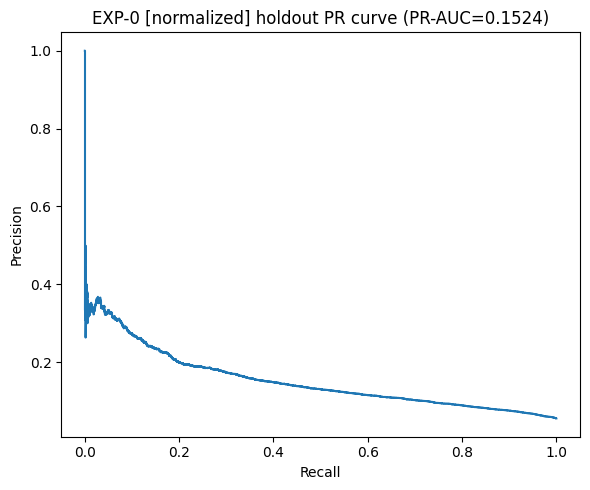

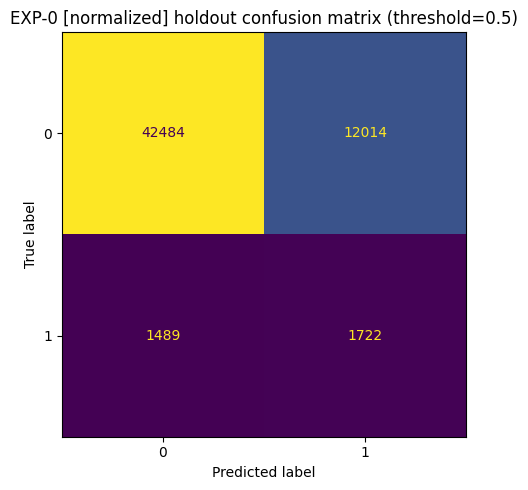

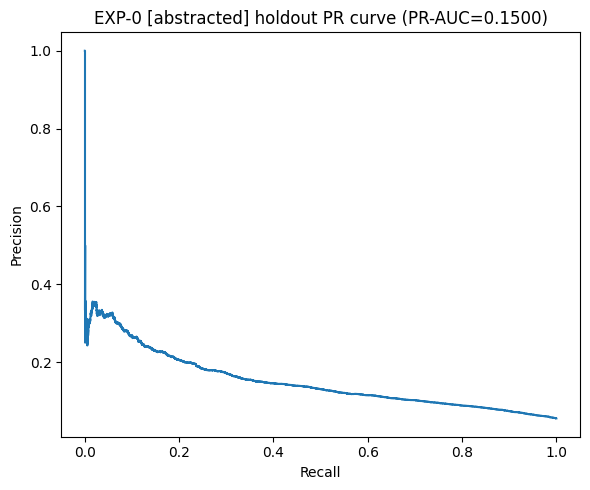

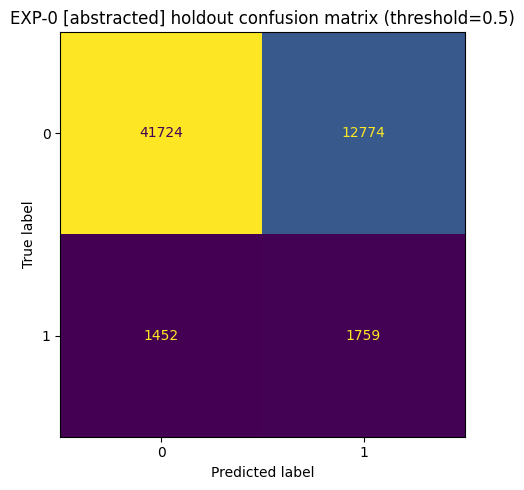

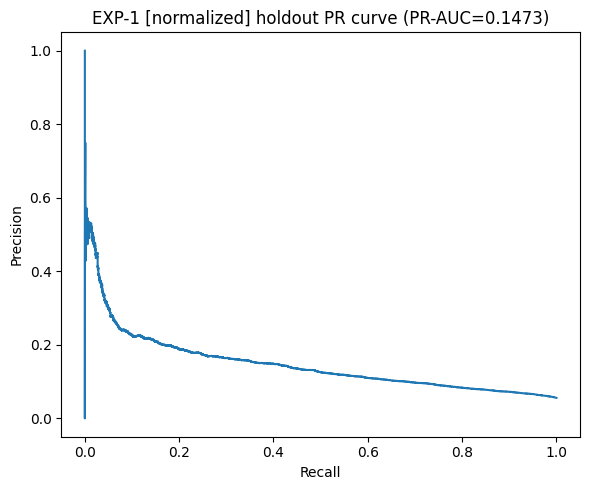

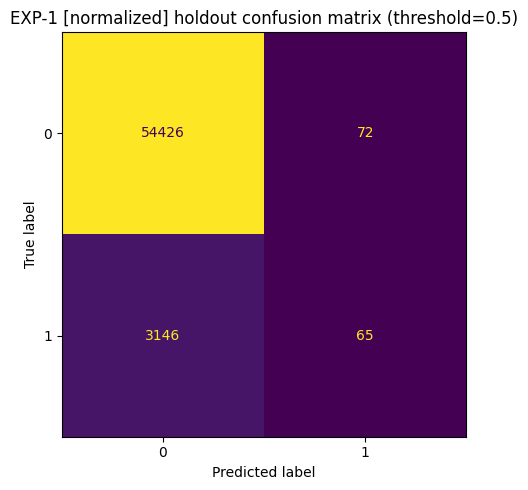

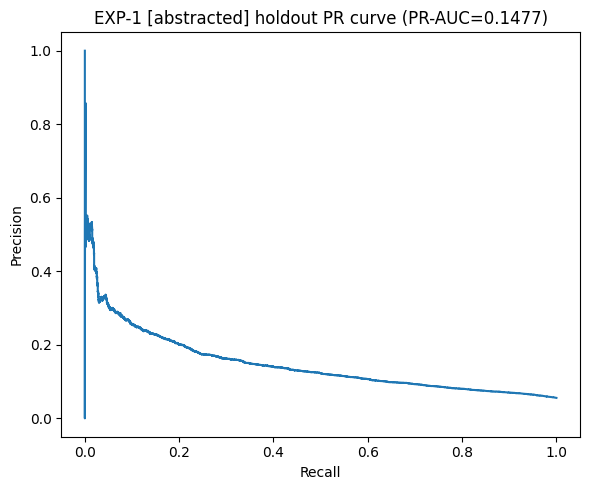

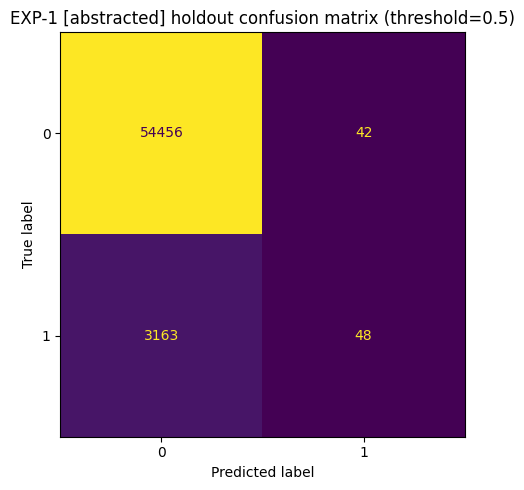

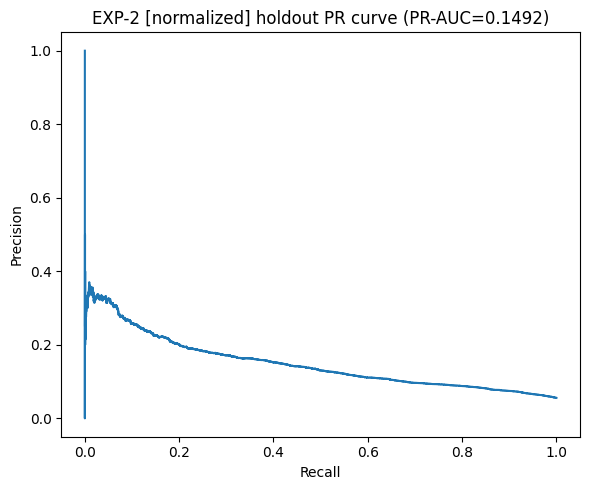

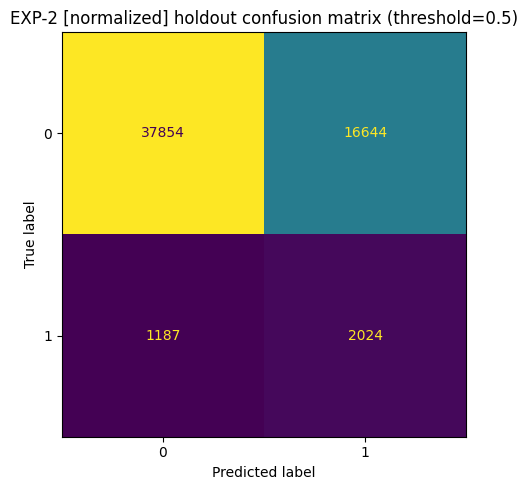

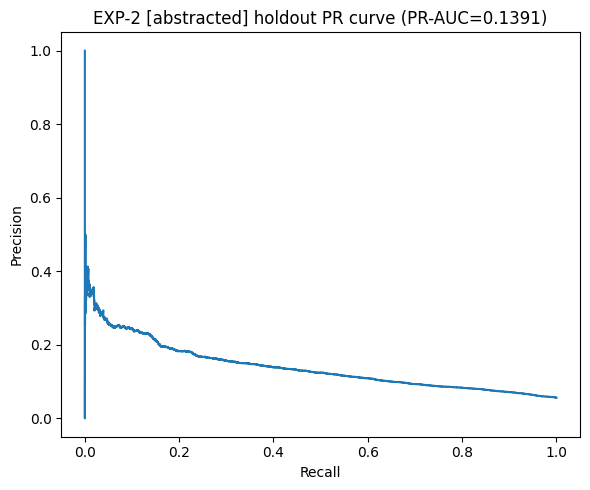

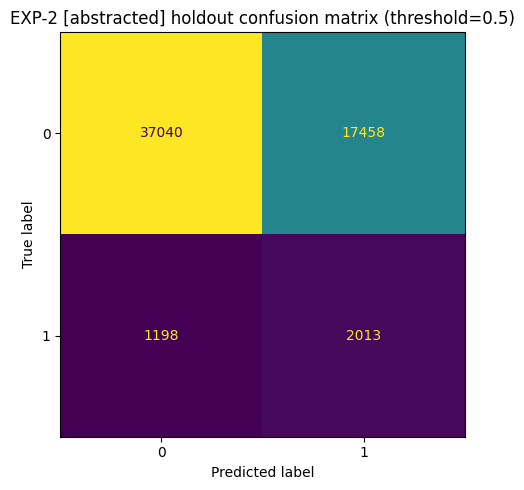

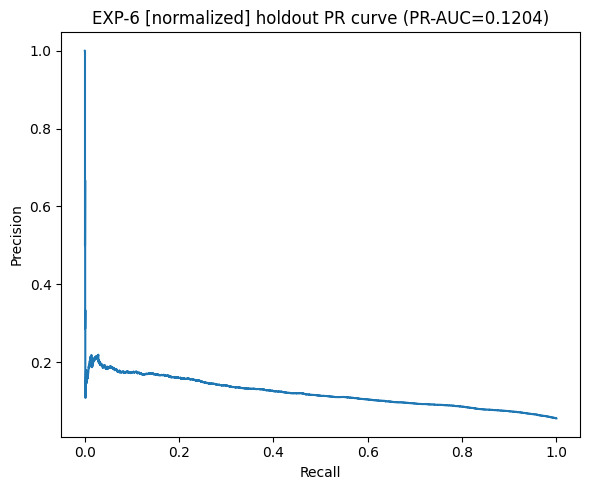

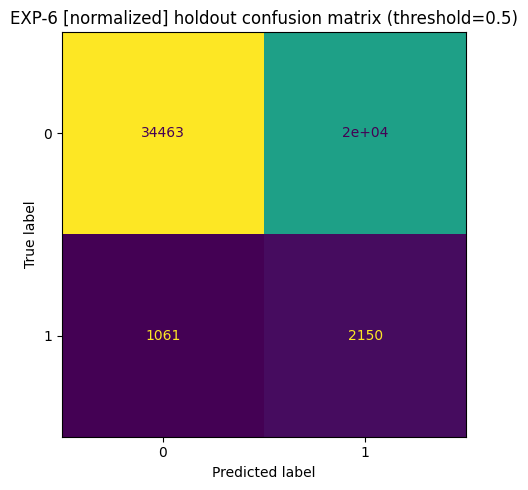

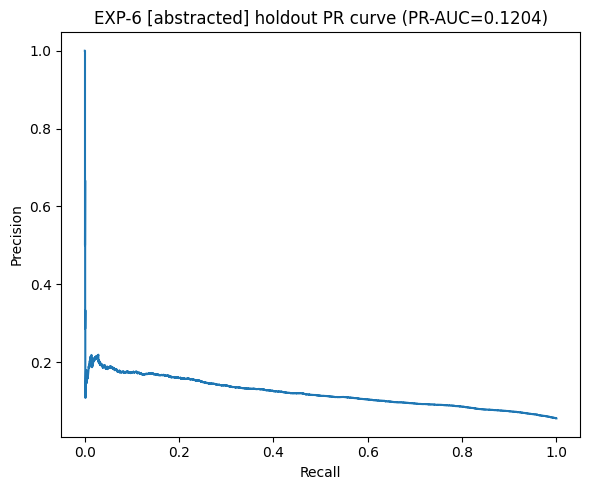

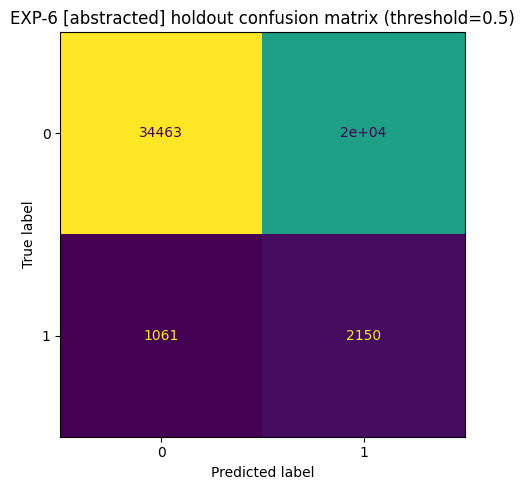

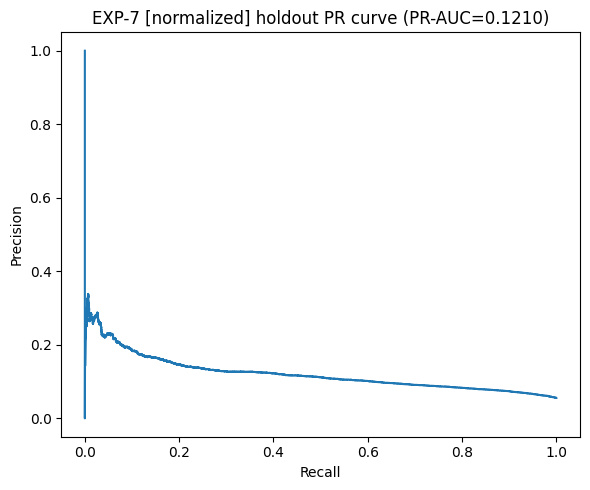

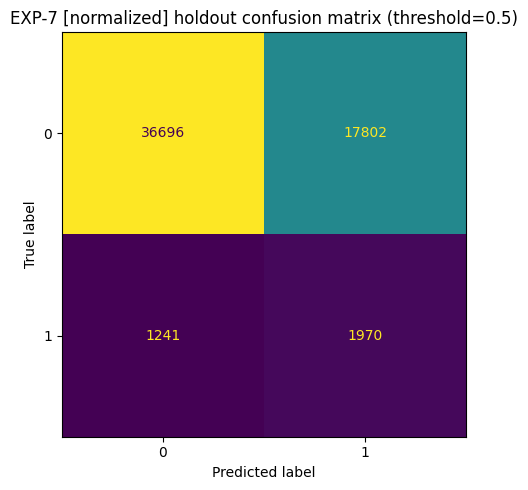

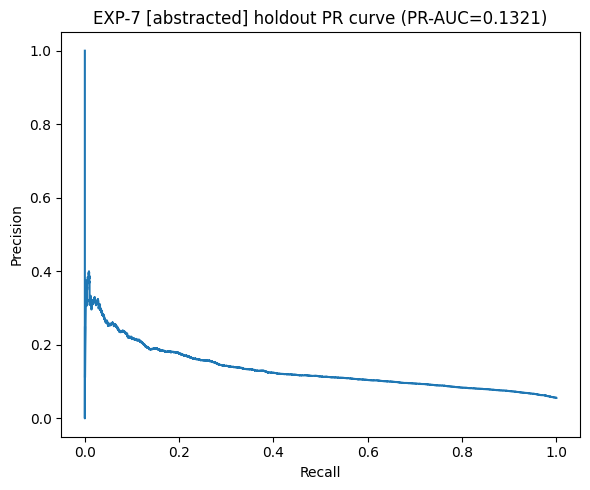

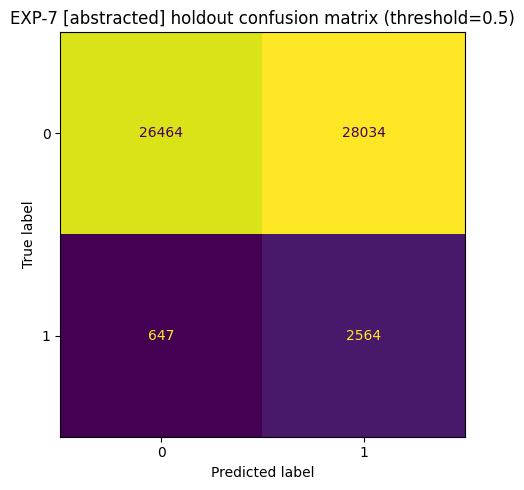

Saved per-experiment figures for 10 experiment x variant run(s) under /workspace/IntelligentSystemProject/VulnerabilityDetectionData/outputs/unified_figures


In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

# One subfolder per experiment inside FIGURES_DIR, containing that
# experiment's own PR curve and confusion matrix for both preprocessing
# variants, in PNG and PDF. This is separate from the "unified" cross-
# experiment plots above, which stay directly in FIGURES_DIR.
DECISION_THRESHOLD = 0.5  # matches confidence_intervals.py's fixed threshold
                          # for precision/recall/F1 used throughout this notebook

for r in records:
    spec = r["spec"]
    exp_dir = FIGURES_DIR / spec["id"]
    exp_dir.mkdir(parents=True, exist_ok=True)

    frame = r["holdout_predictions"]
    y_true = frame["label"].to_numpy()
    y_score = frame["y_score"].to_numpy()
    y_pred = (y_score >= DECISION_THRESHOLD).astype(int)
    pr_auc = r["ci"]["holdout"]["average_precision_pr_auc"].point_estimate

    # Precision-recall curve for this experiment and variant only.
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(recall, precision)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"{spec['id']} [{r['tag']}] holdout PR curve (PR-AUC={pr_auc:.4f})")
    plt.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(exp_dir / f"{spec['id']}_{r['tag']}_pr_curve.{ext}")
    plt.show()
    plt.close(fig)

    # Confusion matrix at the same fixed 0.5 threshold used for precision,
    # recall, and F1 elsewhere in this notebook.
    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, colorbar=False)
    ax.set_title(f"{spec['id']} [{r['tag']}] holdout confusion matrix (threshold={DECISION_THRESHOLD})")
    plt.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(exp_dir / f"{spec['id']}_{r['tag']}_confusion_matrix.{ext}")
    plt.show()
    plt.close(fig)

print(f"Saved per-experiment figures for {len(records)} experiment x variant run(s) under {FIGURES_DIR}")


## 17. Training curves (EXP-2, EXP-7 canonical runs)


In [18]:
TRAINING_CURVE_EXPERIMENTS = {"EXP-2", "EXP-7"}


def _pick_column(frame, *candidates):
    for candidate in candidates:
        if candidate in frame.columns:
            return candidate
    return None


# Only EXP-2 (MLP) and EXP-7 (NeoBERT LoRA) train over epochs with early
# stopping; EXP-0/EXP-1/EXP-3/EXP-6 have no per-epoch curve (linear/ensemble
# models, or a frozen-embedding linear probe), and EXP-4/EXP-5/EXP-8 are out
# of scope (not run going forward). EXP-2's history is saved by every dev-CV
# run; EXP-7's history is only saved by canonical retrains run after the fix
# that made train_lora_model return it -- older EXP-7 outputs will show
# "no training history CSV found" until re-run.
for r in records:
    exp_id = r["spec"]["id"]
    if exp_id not in TRAINING_CURVE_EXPERIMENTS:
        continue

    search_dir = r["spec"]["dirs"](r["tag"])["holdout"]
    history_matches = sorted(search_dir.glob("*training_history*.csv"))
    if not history_matches:
        print(f"{exp_id} [{r['tag']}]: no training history CSV found in {search_dir} -- skipping (re-run canonical retrain to generate it).")
        continue

    history_df = pd.read_csv(history_matches[0])
    pr_auc_col = _pick_column(history_df, "validation_pr_auc", "val_pr_auc")
    train_loss_col = _pick_column(history_df, "train_weighted_bce_loss", "train_loss")
    val_loss_col = _pick_column(history_df, "validation_weighted_bce_loss", "val_loss")
    if pr_auc_col is None or train_loss_col is None or val_loss_col is None:
        print(f"{exp_id} [{r['tag']}]: {history_matches[0]} has unrecognized columns {list(history_df.columns)} -- skipping.")
        continue

    groups = history_df.groupby("fold") if "fold" in history_df.columns else [(None, history_df)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for fold_value, group in groups:
        label = f"fold {fold_value}" if fold_value is not None else "canonical"
        axes[0].plot(group["epoch"], group[pr_auc_col], marker="o", label=label)
        axes[1].plot(group["epoch"], group[train_loss_col], linestyle="--", label=f"{label} train")
        axes[1].plot(group["epoch"], group[val_loss_col], label=f"{label} val")

    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Validation PR-AUC")
    axes[0].set_title(f"{exp_id} [{r['tag']}] validation PR-AUC by epoch")
    axes[0].legend(fontsize=7)

    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].set_title(f"{exp_id} [{r['tag']}] train vs validation loss by epoch")
    axes[1].legend(fontsize=7)

    plt.tight_layout()
    exp_fig_dir = FIGURES_DIR / exp_id
    exp_fig_dir.mkdir(parents=True, exist_ok=True)
    for ext in ("png", "pdf"):
        fig.savefig(exp_fig_dir / f"{exp_id}_{r['tag']}_training_curve.{ext}")
    plt.show()
    plt.close(fig)


EXP-2 [normalized]: no training history CSV found in /workspace/IntelligentSystemProject/VulnerabilityDetectionData/outputs/cs1_project_holdout20_innercv_v1/exp2_mlp_idabs_final_holdout_v2_normalized -- skipping (re-run canonical retrain to generate it).
EXP-2 [abstracted]: no training history CSV found in /workspace/IntelligentSystemProject/VulnerabilityDetectionData/outputs/cs1_project_holdout20_innercv_v1/exp2_mlp_idabs_final_holdout_v2_abstracted -- skipping (re-run canonical retrain to generate it).
EXP-7 [normalized]: no training history CSV found in /workspace/IntelligentSystemProject/VulnerabilityDetectionData/outputs/case_study_2/exp7_neobert_lora_v1_normalized -- skipping (re-run canonical retrain to generate it).
EXP-7 [abstracted]: no training history CSV found in /workspace/IntelligentSystemProject/VulnerabilityDetectionData/outputs/case_study_2/exp7_neobert_lora_v1_abstracted -- skipping (re-run canonical retrain to generate it).
